In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('Algerian_forest_fires_cleaned_dataset_practice.csv')

In [4]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [5]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [6]:
#drop month day and year
df.drop(['day','month','year'],axis=1,inplace=True)

In [7]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [8]:
df['Classes']=np.where(df['Classes'].str.contains('not fire'),0,1)

In [9]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
242,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


In [10]:
X = df.drop('FWI',axis=1)
y = df['FWI']

In [11]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [12]:
y.head()

0    0.5
1    0.4
2    0.1
3    0.0
4    0.5
Name: FWI, dtype: float64

In [13]:
!pip list

Package                   Version
------------------------- --------------
anyio                     4.11.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.3.0
asttokens                 3.0.0
async-lru                 2.0.5
attrs                     25.4.0
babel                     2.17.0
beautifulsoup4            4.14.2
bleach                    6.2.0
certifi                   2025.10.5
cffi                      2.0.0
charset-normalizer        3.4.4
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.17
decorator                 5.2.1
defusedxml                0.7.1
executing                 2.2.1
fastjsonschema            2.21.2
fonttools                 4.60.1
fqdn                      1.5.1
h11                       0.16.0
httpcore                  1.0.9
httpx                     0.28.1
idna                      3.11
ipykernel     

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=4)

In [15]:
X_train.shape, X_test.shape

((182, 11), (61, 11))

In [16]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.664818,-0.235855,-0.250701,0.668095,0.448948,0.311670,0.609202,0.415420,0.523766,0.315730
RH,-0.664818,1.000000,0.229167,0.183044,-0.643988,-0.384796,-0.180585,-0.673178,-0.325724,-0.415444,-0.412660
Ws,-0.235855,0.229167,1.000000,0.138122,-0.139529,0.014909,0.096252,0.048344,0.047191,-0.036462,-0.168007
Rain,-0.250701,0.183044,0.138122,1.000000,-0.523092,-0.305833,-0.333598,-0.356732,-0.325547,-0.396345,0.032995
FFMC,0.668095,-0.643988,-0.139529,-0.523092,1.000000,0.595815,0.504017,0.728253,0.590707,0.769253,0.258363
DMC,0.448948,-0.384796,0.014909,-0.305833,0.595815,1.000000,0.858699,0.657396,0.980863,0.570048,0.240437
DC,0.311670,-0.180585,0.096252,-0.333598,0.504017,0.858699,1.000000,0.476962,0.930188,0.508209,-0.078162
ISI,0.609202,-0.673178,0.048344,-0.356732,0.728253,0.657396,0.476962,1.000000,0.622776,0.711186,0.293289
BUI,0.415420,-0.325724,0.047191,-0.325547,0.590707,0.980863,0.930188,0.622776,1.000000,0.582057,0.127547
Classes,0.523766,-0.415444,-0.036462,-0.396345,0.769253,0.570048,0.508209,0.711186,0.582057,1.000000,0.183995


<Axes: >

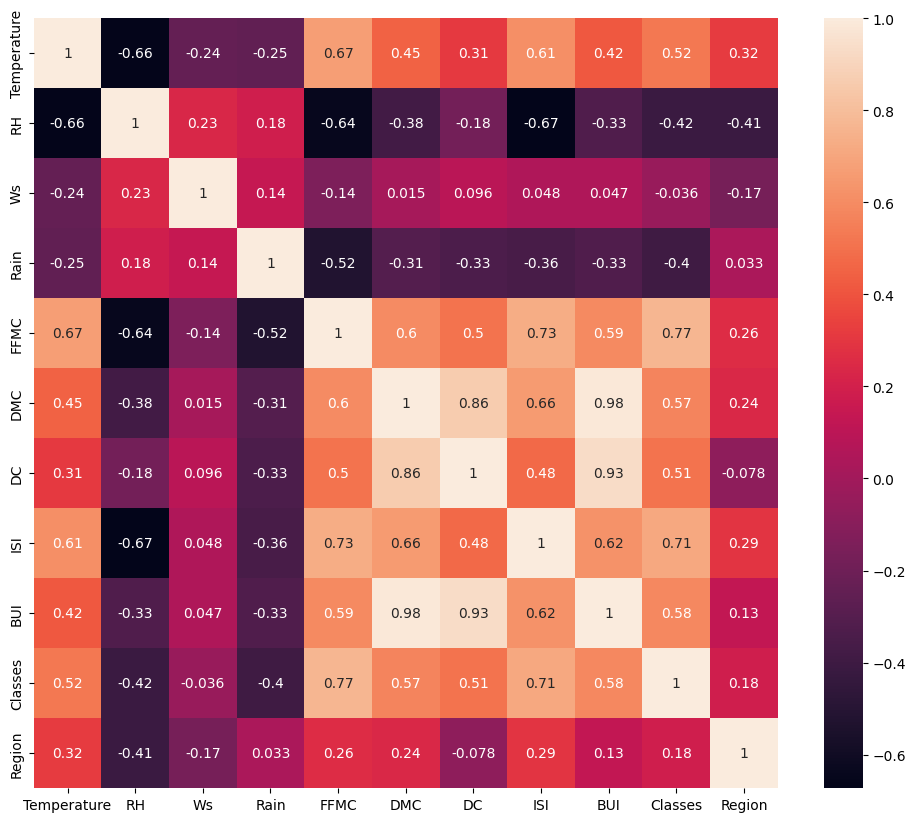

In [17]:
## Check for multicollinearity
plt.figure(figsize=(12,10))
corr=X_train.corr()
sns.heatmap(corr,annot=True)


In [18]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: 
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [19]:
## threshold--Domain expertise
corr_features=correlation(X_train,0.85)

In [20]:
## drop features when correlation is more than 0.85 
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)
X_train.shape,X_test.shape

((182, 9), (61, 9))

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
X_train_scaled

array([[-0.91262417, -0.29012494, -0.50080191, ...,  0.69296783,
         0.84674738, -1.03352882],
       [-0.63671454, -0.48617472, -0.50080191, ..., -0.83618894,
        -1.18098977,  0.96755889],
       [ 0.466924  ,  0.55942409,  0.20575582, ...,  0.1283561 ,
         0.84674738,  0.96755889],
       ...,
       [ 2.1223818 , -1.79317323, -0.50080191, ...,  2.10449715,
         0.84674738,  0.96755889],
       [ 0.19101436,  0.10197461,  0.55903469, ..., -0.76561247,
        -1.18098977,  0.96755889],
       [-0.08489527,  0.62477401, -1.20735964, ..., -1.00086736,
        -1.18098977,  0.96755889]], shape=(182, 9))

Text(0.5, 1.0, 'X_train After Scaling')

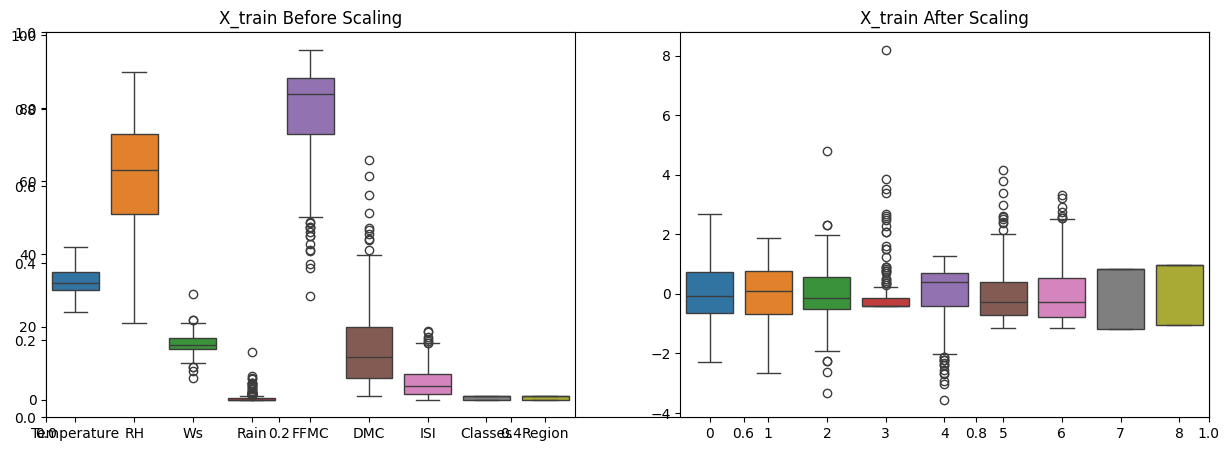

In [23]:
plt.subplots(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title('X_train Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train After Scaling')

Mean Absolute Error:  0.6778288687520768
R2 Score:  0.9836634530297976


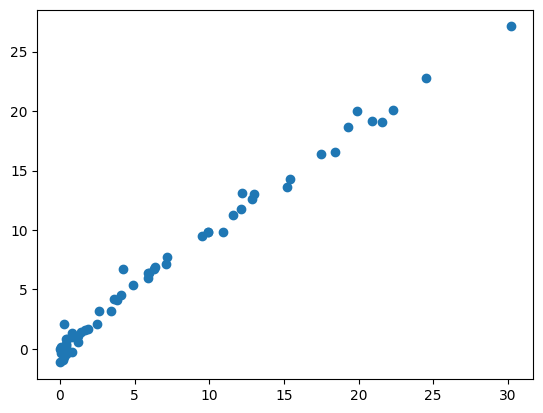

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
linreg=LinearRegression()
linreg.fit(X_train_scaled,y_train)
y_pred=linreg.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean Absolute Error: ",mae)
print("R2 Score: ",score)
plt.scatter(y_test,y_pred)

Mean absolute error 1.3250281717391887
R2 Score 0.9391536149835099


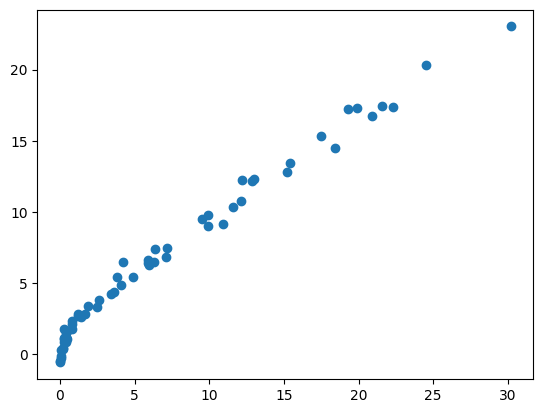

In [25]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso=Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred=lasso.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

In [26]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train_scaled,y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [27]:
lassocv.alpha_

np.float64(0.03871546285369166)

In [28]:
lassocv.alphas_

array([6.76563709, 6.30965579, 5.88440611, 5.48781683, 5.11795634,
       4.77302321, 4.45133742, 4.15133218, 3.87154629, 3.61061702,
       3.36727352, 3.14033055, 2.92868279, 2.73129937, 2.54721893,
       2.3755449 , 2.21544113, 2.06612781, 1.92687771, 1.7970126 ,
       1.67589997, 1.56294992, 1.45761232, 1.35937413, 1.26775686,
       1.1823143 , 1.10263027, 1.02831668, 0.95901158, 0.89437741,
       0.83409936, 0.77788386, 0.72545709, 0.67656371, 0.63096558,
       0.58844061, 0.54878168, 0.51179563, 0.47730232, 0.44513374,
       0.41513322, 0.38715463, 0.3610617 , 0.33672735, 0.31403306,
       0.29286828, 0.27312994, 0.25472189, 0.23755449, 0.22154411,
       0.20661278, 0.19268777, 0.17970126, 0.16759   , 0.15629499,
       0.14576123, 0.13593741, 0.12677569, 0.11823143, 0.11026303,
       0.10283167, 0.09590116, 0.08943774, 0.08340994, 0.07778839,
       0.07254571, 0.06765637, 0.06309656, 0.05884406, 0.05487817,
       0.05117956, 0.04773023, 0.04451337, 0.04151332, 0.03871

In [29]:
lassocv.mse_path_

array([[47.85455631, 88.23307321, 51.43890984, 47.89950548, 28.98978597],
       [42.87097481, 88.23307321, 44.91536505, 41.10093288, 25.54321374],
       [38.51953716, 88.23307321, 40.12834004, 36.02450044, 22.26521739],
       [34.71904989, 80.43612963, 35.44190833, 31.42983367, 19.36476208],
       [31.0354078 , 72.57489689, 31.16898836, 27.4786743 , 16.85699037],
       [27.16118264, 65.65105874, 27.43962954, 24.08401835, 14.68968761],
       [23.79351269, 59.54835102, 24.18376554, 21.17077105, 12.81773081],
       [20.86617236, 52.59648359, 21.34087948, 18.67348368, 11.20169325],
       [18.32138731, 46.48834346, 18.85776929, 16.53551658,  9.80742598],
       [16.10984094, 41.13841336, 16.68828229, 14.70759678,  8.60528299],
       [14.18771921, 36.45007336, 14.79222952, 13.14754453,  7.56948917],
       [12.51723184, 32.33952589, 13.13461215, 11.81830721,  6.67780816],
       [11.0655172 , 28.73372811, 11.68477728, 10.68795956,  5.91080171],
       [ 9.80399973, 25.56900181, 10.4

Mean absolute error 0.7152065722492388
R2 Score 0.9821007534310031


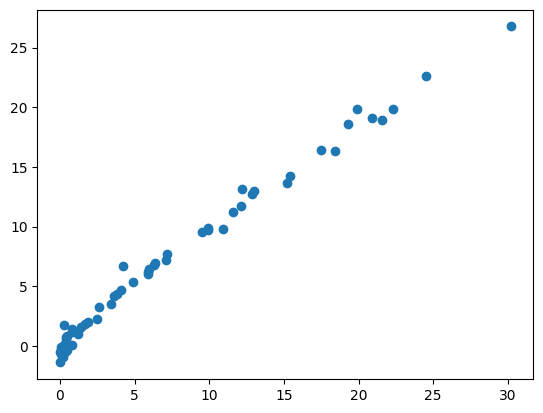

In [30]:
y_pred=lassocv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

Mean absolute error 0.6945660040306076
R2 Score 0.9829919664016084


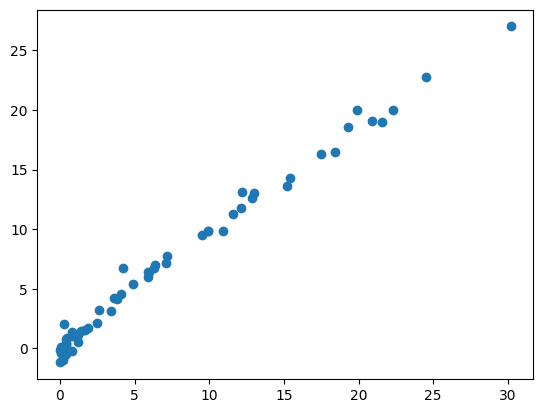

In [31]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred=ridge.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

Mean absolute error 0.6945660040306076
R2 Score 0.9829919664016084


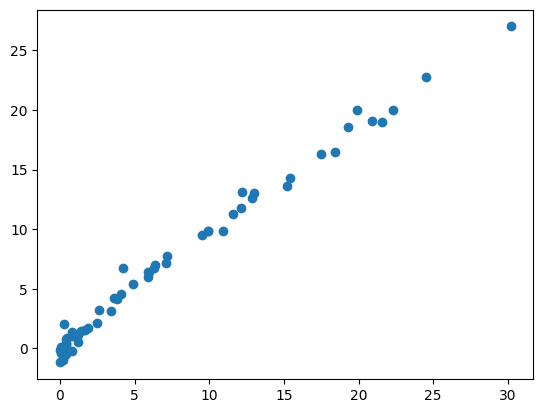

In [32]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)
y_pred=ridgecv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

Mean absolute error 1.85544215763124
R2 Score 0.882388680753389


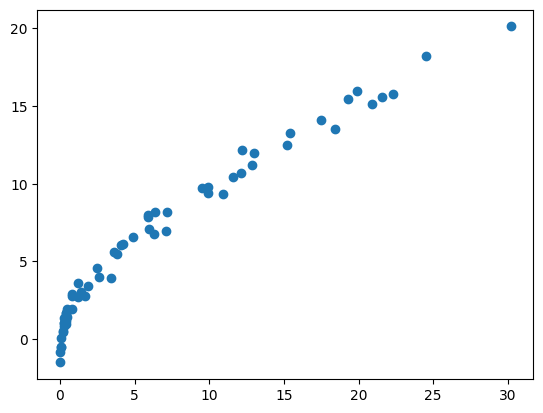

In [33]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elastic=ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred=elastic.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

Mean absolute error 0.720214431095874
R2 Score 0.9817290149849079


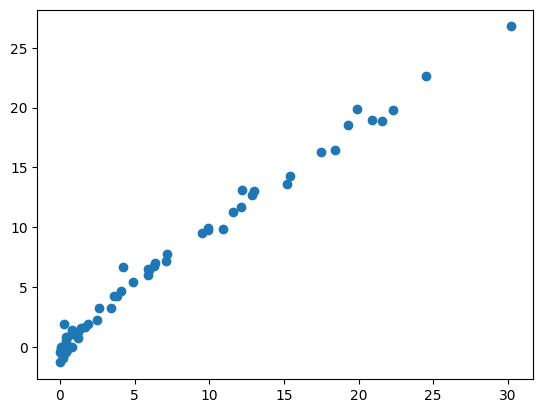

In [34]:
from sklearn.linear_model import ElasticNetCV
elasticcv=ElasticNetCV(cv=5)
elasticcv.fit(X_train_scaled,y_train)
y_pred=elasticcv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

In [35]:
elasticcv.alphas_

array([13.53127417, 12.61931158, 11.76881221, 10.97563366, 10.23591269,
        9.54604643,  8.90267485,  8.30266436,  7.74309257,  7.22123405,
        6.73454704,  6.28066111,  5.85736557,  5.46259874,  5.09443786,
        4.7510898 ,  4.43088225,  4.13225562,  3.85375542,  3.5940252 ,
        3.35179993,  3.12589983,  2.91522465,  2.71874826,  2.53551373,
        2.36462859,  2.20526054,  2.05663336,  1.91802315,  1.78875481,
        1.66819872,  1.55576771,  1.45091418,  1.35312742,  1.26193116,
        1.17688122,  1.09756337,  1.02359127,  0.95460464,  0.89026748,
        0.83026644,  0.77430926,  0.7221234 ,  0.6734547 ,  0.62806611,
        0.58573656,  0.54625987,  0.50944379,  0.47510898,  0.44308823,
        0.41322556,  0.38537554,  0.35940252,  0.33517999,  0.31258998,
        0.29152246,  0.27187483,  0.25355137,  0.23646286,  0.22052605,
        0.20566334,  0.19180232,  0.17887548,  0.16681987,  0.15557677,
        0.14509142,  0.13531274,  0.12619312,  0.11768812,  0.10

In [36]:
scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [37]:
Ridge

sklearn.linear_model._ridge.Ridge

In [40]:
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(ridge,open('ridge.pkl','wb'))